# Práctica 3




In [10]:
#===================================
# Importamos los modulos a utilizar
#===================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import statsmodels.api as sm
from matplotlib.pyplot import subplot


## **1.Preprocesamiento**
Supongamos que los valores de un conjunto determinado de datos se
agrupan en intervalos. Los intervalos y las frecuencias correspondientes
son los siguientes:

| Edad   | Frecuencia   |
|---------|---------|
| 1-5 | 650|
| 5-15 | 900 |
| 15-20 | 1850 |
| 20-50 | 850 |
| 50-80 | 500 |
| 80-110| 90 |

Calcular un valor medio aproximado
para los datos.


En cada grupo no sabemos de manera precisa cuantas personas tienen 1,2,3,4, o 5 años en el primer ejemplo. Por lo que se tendrá que aproximar a que el número de personas se distribuye de manera uniforme en cada grupo.

De esta manera se calcula el valor medio de cada grupo y se multiplica por su frecuencia para poder obtener un valor medio aproximado para todos los datos.

(1 a 5) $ → \frac{1+5}{2} = 3$

(5 a 15) $ → \frac{5+15}{2} = 10$

(15 a 20) $ → \frac{15+20}{2} = 17.5$

(20 a 50) $ → \frac{20+50}{2} = 35$

(50 a 80) $ → \frac{50+80}{2} = 65$

(80 a 110) $ → \frac{80+110}{2} = 95$

In [8]:
round((3*650+10*900+17.5*1850+35*850+65*500+95*90) / (650+900+1850+850+500+90), 1)

23.6

Por lo tanto, el valor medio aproximado para los datos es de 24 años.

## **2.Estadísticas**
Supongamos que los datos para el análisis incluyen el atributo de Edad
Los valores de la edad para las tuplas de datos son (en orden creciente)
12, 15, 15, 16, 19,19, 20, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33,
34, 35, 35, 35, 35, 36, 36, 42, 45, 46, 52, 71, 76, 78

**a) ¿Cuál es la media de los datos? ¿Cuál es la mediana?**

**b) ¿Cuál es la moda de los datos?**

**c) Utilice la normalización min-max para transformar el valor 49 de la antigüedad en el intervalo [0.0,1.0].**

**d) Trazar un histograma de equi-distancia de longitud 7**

In [11]:
datos = [12, 15, 15, 16, 19,19, 20, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33, 34, 35, 35, 35, 35, 36, 36, 42, 45, 46, 52, 71, 76, 78]
print("Media de los datos {}".format(np.mean(datos)))
print("Mediana de los datos {}".format(np.median(datos)))
print("Moda de los datos {}".format(stats.mode(datos)))


Media de los datos 32.515151515151516
Mediana de los datos 30.0
Moda de los datos ModeResult(mode=25, count=4)


Para la normalización min-max consideramos al valor minimo y al valor maximo de los datos, en este caso, 12 y 78.

$$⇒ (49)' = \frac{49 - (min)_{datos}}{(max)_{datos} - (min)_{datos}} = \frac{49-12}{78-12} = .56$$

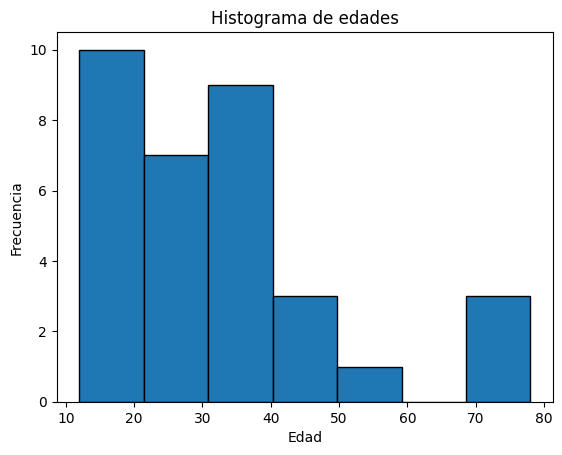

In [17]:
# Crear el histograma
plt.hist(datos, bins=7, edgecolor='black')
# Etiquetas y título
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de edades')
# Mostrar el gráfico
plt.show()

## **3.Preprocesamiento**
Supongamos que un hospital probó los datos de edad y grasa corporal para 18 adultos
seleccionados al azar con el siguiente resultado


**a) Calcule la media, la mediana y la desviación estándar de la edad y % Grasa.**

**b) Grafica el diagrama de dispersión**

**c) Normaliza los datos de Edad y % Grasa**

**d) Calcula y explica el coeficiente de correlación de Pearson**



In [18]:
df = pd.DataFrame({'Edad': [22, 23, 27, 27, 39, 42, 47, 49, 50, 52, 54, 54, 56, 57, 59, 59, 62, 66],
                   '%_Grasa': [9.5, 26.5, 7.7, 18.8, 31.4, 25.9, 27.5, 27.2, 31.3, 34.5, 42.5, 28.9, 33.5, 30.2, 34.1, 33.3, 41.4, 35.7]})
df.describe()

,Edad,%_Grasa
count,18.000000,18.000000
mean,46.944444,28.883333
std,13.892326,9.227469
min,22.000000,7.700000
25%,39.750000,26.675000
50%,51.000000,30.750000
75%,56.750000,33.950000
max,66.000000,42.500000


*   Media de Edad: 46.9
*   Media de % Grasa: 28.9
*   Mediana de Edad: 51
*   Mediana de % Grasa: 30.75
*   Desviación Estándar de Edad: 13.89
*   Desviación Estándar de % Grasa: 9.23

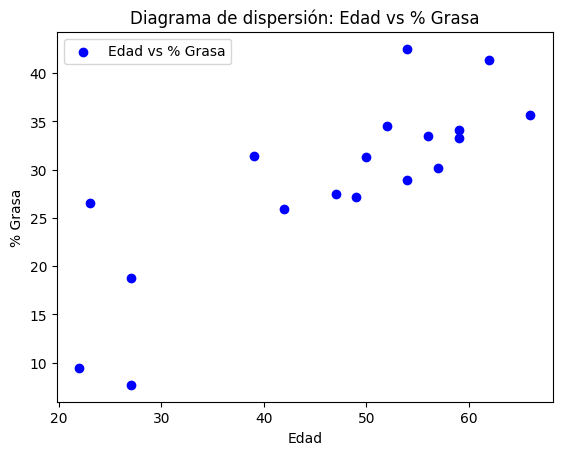

In [20]:
# Graficar el diagrama de dispersión
plt.scatter(df['Edad'], df['%_Grasa'], color='b', label='Edad vs % Grasa')
# Etiquetas y título
plt.xlabel('Edad')
plt.ylabel('% Grasa')
plt.title('Diagrama de dispersión: Edad vs % Grasa')
plt.legend()
# Mostrar la gráfica
plt.show()

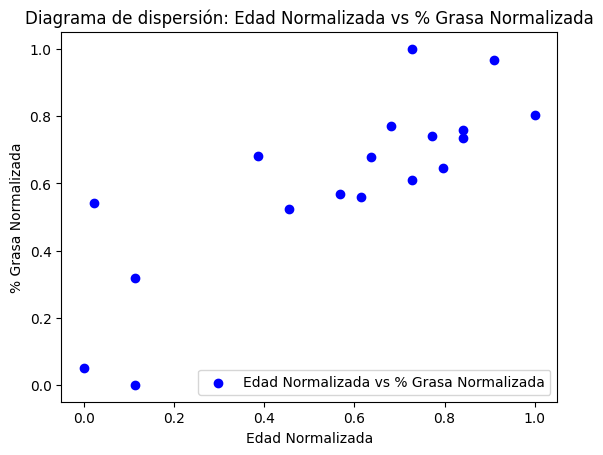

In [23]:
df['Edad_Normalizada'] = (df['Edad'] - df['Edad'].min()) / (df['Edad'].max() - df['Edad'].min())
df['%_Grasa_Normalizada'] = (df['%_Grasa'] - df['%_Grasa'].min()) / (df['%_Grasa'].max() - df['%_Grasa'].min())

# Graficar el diagrama de dispersión
plt.scatter(df['Edad_Normalizada'], df['%_Grasa_Normalizada'], color='b', label='Edad Normalizada vs % Grasa Normalizada')
# Etiquetas y título
plt.xlabel('Edad Normalizada')
plt.ylabel('% Grasa Normalizada')
plt.title('Diagrama de dispersión: Edad Normalizada vs % Grasa Normalizada')
plt.legend()
# Mostrar la gráfica
plt.show()


In [25]:
# Calcular el coeficiente de correlación de Pearson
correlacion = df['Edad'].corr(df['%_Grasa'])
print(f"Coeficiente de correlación de Pearson: {correlacion}")

Coeficiente de correlación de Pearson: 0.8153657028511001


Existe una relación positiva fuerte entre la Edad y el % de Grada, es decir, a mayor edad es más seguro tener mayor % de grasa.

## **4.Distancias**
Cálculo de distancias, atributos numéricos
Sean las tuplas: X1=(6,2) y X2=(5,9)
Encuentre la distancia utilizando:

**a) Distancia máxima**

**b) Distancia de Manhattan**

**c) Distancia Euclidiana**

Expresar gráficamente los resultados



In [26]:
# Definir las tuplas
X1 = np.array([6, 2])
X2 = np.array([5, 9])

# a) Distancia Máxima (Distancia Chebyshev)
dist_max = np.max(np.abs(X1 - X2))

# b) Distancia de Manhattan
dist_manhattan = np.sum(np.abs(X1 - X2))

# c) Distancia Euclidiana
dist_euclidiana = np.linalg.norm(X1 - X2)

# Mostrar los resultados
print(f"Distancia Máxima: {dist_max}")
print(f"Distancia de Manhattan: {dist_manhattan}")
print(f"Distancia Euclidiana: {dist_euclidiana}")

Distancia Máxima: 7
Distancia de Manhattan: 8
Distancia Euclidiana: 7.0710678118654755


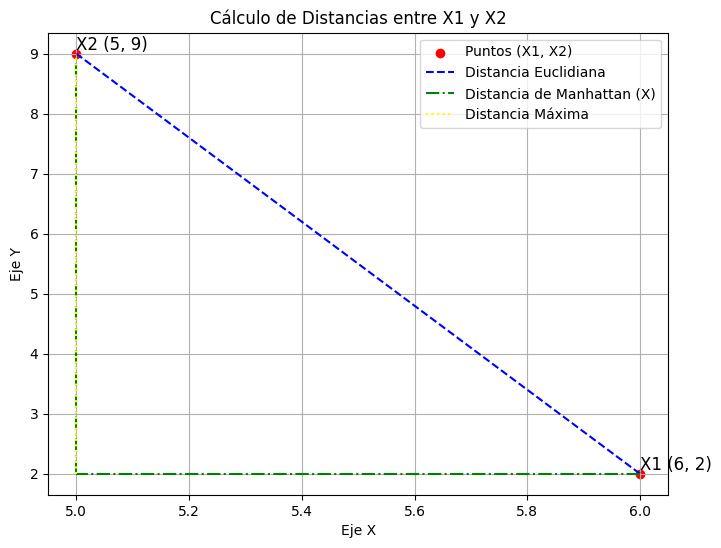

In [30]:
# Graficar los puntos y las distancias
plt.figure(figsize=(8, 6))
# Puntos X1 y X2
plt.scatter([X1[0], X2[0]], [X1[1], X2[1]], color='red', label='Puntos (X1, X2)')

# Etiquetas de los puntos
plt.text(X1[0], X1[1], f'X1 ({X1[0]}, {X1[1]})', fontsize=12, verticalalignment='bottom')
plt.text(X2[0], X2[1], f'X2 ({X2[0]}, {X2[1]})', fontsize=12, verticalalignment='bottom')
# Dibujar las líneas de las distancias
plt.plot([X1[0], X2[0]], [X1[1], X2[1]], 'blue', linestyle='--', label='Distancia Euclidiana')
# Líneas de las distancias de Manhattan (horizontal y vertical)
plt.plot([X1[0], X2[0]], [X1[1], X1[1]], 'green', linestyle='-.', label='Distancia de Manhattan (X)')
plt.plot([X2[0], X2[0]], [X1[1], X2[1]], 'green', linestyle='-.')
# Líneas de la distancia máxima
plt.plot([X2[0], X2[0]], [X1[1], X2[1]], 'yellow', linestyle=':', label='Distancia Máxima')
# Etiquetas y título
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Cálculo de Distancias entre X1 y X2')
plt.legend()
plt.grid(True)
plt.show()


## **5.Distancias**

**a) Agrega tus datos y realiza lo siguiente**

**b) Utilizando distancia Euclidiana, encuentre la distancia entre las tuplas 2 y 6**

**c) Utilizando distancia Euclidiana, encuentre la distancia entre las tuplas 3 y 8**

**d) Realiza lo mismo con la distancia de Manhattan y Mahalanobis**

**e) Normaliza la edad**




In [41]:
df = pd.DataFrame({'ID': [1,2,3,4,5,6,7, 8],
                   'Color_ojos': ["Café", "Negro", "Azul", "Negro", "Café", "Verde", "Negro", "Negro"],
                   'Sexo': ["M", "F", "F", "F", "M", "M", "F", "M"],
                   'Edad': [25, 23, 29, 27 ,23 ,28 ,26, 26]
                   })
df

,ID,Color_ojos,Sexo,Edad
0,1,Café,M,25
1,2,Negro,F,23
2,3,Azul,F,29
3,4,Negro,F,27
4,5,Café,M,23
5,6,Verde,M,28
6,7,Negro,F,26
7,8,Negro,M,26


**Distancia Euclidiana**

$d(x_2, x_6) = \sqrt(1^{2} + 1^{2} + (23-28)^{2}) ≈ 5.19 $

$d(x_3, x_8) = \sqrt(1^{2} + 1^{2} + (29-26)^{2}) ≈ 3.31$

**Distancia Manhattan**

$d(x_2, x_6) = |1| + |1| + |23-28| = 7$

$d(x_3, x_8) = |1| + |1| + |29-26| = 5$

**Distancia Mahalanobis**

$D_{M}(X_1, X_2) = \sqrt((X_1 - X_2)^{T} ∑^{-1} (X_1 - X_2))$

Por lo que calcularemos la matriz de covarianza

In [42]:
# Codificar las variables categóricas
df['Color_ojos'] = df['Color_ojos'].map({'Café': 0, 'Negro': 1, 'Azul': 2, 'Verde': 3})
df['Sexo'] = df['Sexo'].map({'M': 0, 'F': 1})

# Seleccionar solo las columnas relevantes (Color_ojos, Sexo, Edad)
data_for_covariance = df[['Color_ojos', 'Sexo', 'Edad']]

# Calcular la matriz de covarianza
cov_matrix = np.cov(data_for_covariance.T)  # Transponemos para que las variables estén en columnas
print("Matriz de covarianza:")
print(cov_matrix)

# Calcular la inversa de la matriz de covarianza
inv_cov_matrix = np.linalg.inv(cov_matrix)
print("Matriz inversa de covarianza:")
print(inv_cov_matrix)


Matriz de covarianza:
[[0.98214286 0.07142857 1.58928571]
 [0.07142857 0.28571429 0.21428571]
 [1.58928571 0.21428571 4.69642857]]
Matriz inversa de covarianza:
[[ 2.25063291  0.00886076 -0.76202532]
 [ 0.00886076  3.62405063 -0.16835443]
 [-0.76202532 -0.16835443  0.47848101]]


In [46]:
# Seleccionar los registros 2, 6, 3 y 8
X2 = df.iloc[1, 1:].values  # Registro 2
X6 = df.iloc[5, 1:].values  # Registro 6
X3 = df.iloc[2, 1:].values  # Registro 3
X8 = df.iloc[7, 1:].values  # Registro 8

In [47]:
# Calcular la diferencia entre los puntos
delta = X2 - X6
# Calcular la distancia de Mahalanobis
mahalanobis_distance = np.sqrt(np.dot(np.dot(delta.T, inv_cov_matrix), delta))
print(f"La distancia de Mahalanobis entre el Registro 2 y el Registro 6 es: {mahalanobis_distance}")

# Calcular la diferencia entre los puntos
delta = X3 - X8
# Calcular la distancia de Mahalanobis
mahalanobis_distance = np.sqrt(np.dot(np.dot(delta.T, inv_cov_matrix), delta))
print(f"La distancia de Mahalanobis entre el Registro 3 y el Registro 8 es: {mahalanobis_distance}")

La distancia de Mahalanobis entre el Registro 2 y el Registro 6 es: 3.3160522510427315
La distancia de Mahalanobis entre el Registro 3 y el Registro 8 es: 2.148593888151628


**Edad Normalizada**

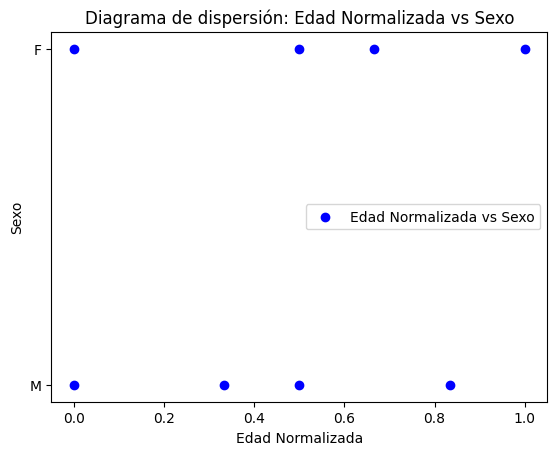

In [37]:
df['Edad_Normalizada'] = (df['Edad'] - df['Edad'].min()) / (df['Edad'].max() - df['Edad'].min())

# Graficar el diagrama de dispersión
plt.scatter(df['Edad_Normalizada'], df['Sexo'], color='b', label='Edad Normalizada vs Sexo')
# Etiquetas y título
plt.xlabel('Edad Normalizada')
plt.ylabel('Sexo')
plt.title('Diagrama de dispersión: Edad Normalizada vs Sexo')
plt.legend()
# Mostrar la gráfica
plt.show()

## **6.Definición de Modelos**
Con los datos anteriores

**a) Calcula/genera la matriz de correlación de datos. Concluye tus resultados.**

**b) Elaborar un modelo de regresión lineal, expresión lineal. Concluye tus resultados.**

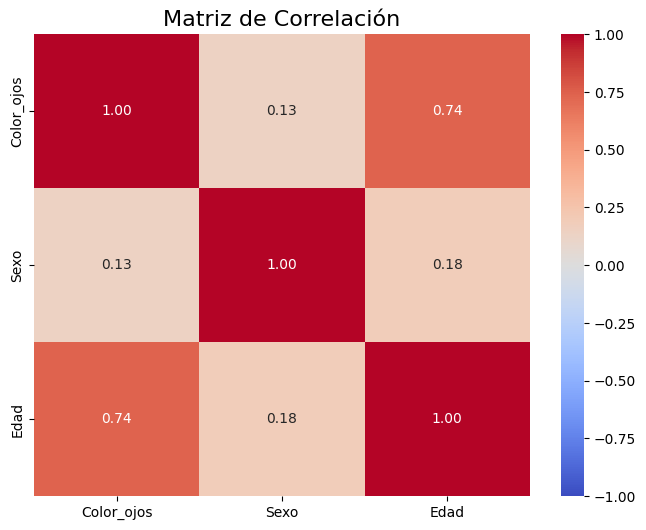

In [49]:
# Calcular la matriz de correlación de todas las variables numéricas
corr_matrix = df[['Color_ojos', 'Sexo', 'Edad']].corr()

# Crear el heatmap con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True, fmt='.2f')

# Ajustar el título y mostrar la gráfica
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

Podemos observar una correlación positiva débil entre las variables Sexo y Color de ojos, también entre las variables Sexo y Edad.

Por otro lado, las variables Edad y Color de ojos presentan una correlación positiva fuerte.


**Modelo de Regresión Lineal**

Dados los resultados vistos en la matriz de correlación, se propone a la Edad como variable dependiente y Sexo y Color de ojos como variables independientes.

In [50]:
# Seleccionar las variables independientes (X) y dependientes (Y)
X = df[['Sexo', 'Color_ojos']]  # Variables independientes
Y = df['Edad']  # Variable dependiente

# Añadir una constante a X para la intersección (bias) del modelo
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(Y, X).fit()

# Mostrar el resumen del modelo
print("\nResumen del modelo de regresión lineal:")
print(model.summary())


Resumen del modelo de regresión lineal:
                            OLS Regression Results                            
Dep. Variable:                   Edad   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     3.118
Date:                Sun, 01 Dec 2024   Prob (F-statistic):              0.132
Time:                        19:25:50   Log-Likelihood:                -13.766
No. Observations:                   8   AIC:                             33.53
Df Residuals:                       5   BIC:                             33.77
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)


El modelo tiene un valor R-cuadrado de .55 lo cual nos indica que el modelo no explica de manera adecuada los datos.

De igual manera con las variables Sexo y Color de Ojos, no son significativas con un 95% de confianza.

Por último, era de esperar que no se pudiera ajustar un buen modelo ya que aunque las variables Edad y Color de Ojos tengan una correlación positiva en estos datos no significa causalidad.